<a href="https://colab.research.google.com/github/banteamlak1888/Floridan-University-Fundamentals-AI-Trianing/blob/main/Practice_Assignment_for_Module_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 2 Assignment:

**Student Name:** Banteamlak Begashaw Shibesh  
**Project Name:** Heart Disease Risk Prediction System using Machine Learning  
**Dataset Selected:** Heart Disease Prediction Dataset (Supervised Classification)  
**Environment:** Google Colab Python 3 Engine  

---

## Question 1 – Understanding the Dataset (2 Marks)

### 1.1 Purpose of the Dataset
The primary purpose of the Heart Disease Prediction dataset is to analyze clinical and physiological patient parameters to predict the presence or absence of cardiovascular disease ($Target = 1$ for Heart Disease present, $Target = 0$ for Absence). In clinical settings, automated decision-support systems leverage these parameters to assist physicians in early risk identification, preventing adverse cardiac events through timely intervention.

### 1.2 Machine Learning Problem Type
This is a **Supervised Binary Classification** problem. The target variable is categorical and discrete ($0$ or $1$), and the model learns a decision boundary mapping continuous and categorical input features to this target.

### 1.3 Input Features and Target Variable

* **Input Features ($X$):**
  * `age`: Patient age in years (Continuous)
  * `sex`: Gender (1 = Male, 0 = Female) (Categorical)
  * `cp`: Chest Pain type (0: Typical Angina, 1: Atypical Angina, 2: Non-anginal Pain, 3: Asymptomatic) (Categorical)
  * `trestbps`: Resting blood pressure in mm Hg upon hospital admission (Continuous)
  * `chol`: Serum cholesterol in mg/dL (Continuous)
  * `fbs`: Fasting blood sugar > 120 mg/dL (1 = True, 0 = False) (Categorical)
  * `restecg`: Resting electrocardiographic results (0, 1, 2) (Categorical)
  * `thalach`: Maximum heart rate achieved during exercise stress test (Continuous)
  * `exang`: Exercise-induced angina (1 = Yes, 0 = No) (Categorical)
  * `oldpeak`: ST depression induced by exercise relative to rest (Continuous)
  * `slope`: Peak exercise ST segment slope (0, 1, 2) (Categorical)
  * `ca`: Number of major vessels (0–4) colored by fluoroscopy (Discrete)
  * `thal`: Thalassemia stress test result (1 = Normal, 2 = Fixed defect, 3 = Reversible defect) (Categorical)

* **Target Variable ($y$):**
  * `target`: Presence of Heart Disease (1 = Diagnosed, 0 = Healthy)

**1.4 Python Code: Dataset Exploration**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set seed for reproducibility
np.random.seed(42)

# --- Synthetic Clinical Dataset Generation (Mirroring UCI Heart Disease Benchmark) ---
def load_heart_disease_data():
    n_samples = 303
    data = {
        'age': np.random.randint(29, 77, size=n_samples),
        'sex': np.random.choice([0, 1], size=n_samples, p=[0.32, 0.68]),
        'cp': np.random.choice([0, 1, 2, 3], size=n_samples, p=[0.47, 0.16, 0.28, 0.09]),
        'trestbps': np.random.randint(94, 200, size=n_samples),
        'chol': np.random.randint(126, 564, size=n_samples),
        'fbs': np.random.choice([0, 1], size=n_samples, p=[0.85, 0.15]),
        'restecg': np.random.choice([0, 1, 2], size=n_samples, p=[0.48, 0.50, 0.02]),
        'thalach': np.random.randint(71, 202, size=n_samples),
        'exang': np.random.choice([0, 1], size=n_samples, p=[0.67, 0.33]),
        'oldpeak': np.round(np.random.uniform(0.0, 6.2, size=n_samples), 1),
        'slope': np.random.choice([0, 1, 2], size=n_samples, p=[0.07, 0.46, 0.47]),
        'ca': np.random.choice([0, 1, 2, 3, 4], size=n_samples, p=[0.58, 0.21, 0.12, 0.07, 0.02]),
        'thal': np.random.choice([1, 2, 3], size=n_samples, p=[0.06, 0.54, 0.40]),
        'target': np.random.choice([0, 1], size=n_samples, p=[0.46, 0.54])
    }
    df = pd.DataFrame(data)

    # Introduce synthetic missing values and duplicates for preprocessing verification
    df.loc[12, 'trestbps'] = np.nan
    df.loc[45, 'chol'] = np.nan
    df.loc[88, 'thal'] = np.nan
    df = pd.concat([df, df.iloc[[10]]], ignore_index=True) # Duplicate record
    return df

# Load dataset
df_raw = load_heart_disease_data()

# --- Question 1 Diagnostic Output ---
print("==================================================")
print("       QUESTION 1: DATA EXPLORATION REPORT        ")
print("==================================================")
print(f"Number of Records (Rows):     {df_raw.shape[0]}")
print(f"Number of Features (Columns): {df_raw.shape[1]}")
print("\n--- Data Types ---")
print(df_raw.dtypes)

print("\n--- Missing Values Count Per Feature ---")
print(df_raw.isnull().sum())

print(f"\nNumber of Duplicate Records:  {df_raw.duplicated().sum()}")
print("\n--- First 5 Records ---")
print(df_raw.head())

       QUESTION 1: DATA EXPLORATION REPORT        
Number of Records (Rows):     304
Number of Features (Columns): 14

--- Data Types ---
age           int64
sex           int64
cp            int64
trestbps    float64
chol        float64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal        float64
target        int64
dtype: object

--- Missing Values Count Per Feature ---
age         0
sex         0
cp          0
trestbps    1
chol        1
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        1
target      0
dtype: int64

Number of Duplicate Records:  1

--- First 5 Records ---
   age  sex  cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0   67    1   0     166.0  274.0    0        1      139      0      2.7   
1   57    0   0     146.0  206.0    1        0      157      1      0.9   
2   43    1   2     102.0  340.0  

**Question 2 – Data Preprocessing (2 Marks)**

## Question 2 – Data Preprocessing (2 Marks)

### 2.1 Rationale for Preprocessing Steps

* **Handling Missing Values:** Machine learning algorithms like Logistic Regression and Random Forests cannot natively process null values. Continuous missing values (`trestbps`, `chol`) are imputed with the column median to minimize vulnerability to extreme clinical outliers. Categorical missing values (`thal`) are imputed with the column mode.
* **Removing Duplicates:** Duplicate observations introduce artificial bias, inflating specific training patterns and causing data leakage between train and test sets during cross-validation.
* **Encoding Categorical Variables:** Multi-class categorical features (`cp`, `restecg`, `slope`, `thal`) represent nominal attributes without inherent ordinal ranking. Applying One-Hot Encoding creates binary indicators, preventing estimators from incorrectly interpreting numerical categories as continuous orderings.
* **Feature Scaling:** Features operate on drastically different scales (e.g., `age` in tens vs. `chol` in hundreds). Distance-sensitive classifiers (such as Logistic Regression, SVM, or $k$-NN) and gradient-descent optimization models misattribute feature importance to larger scales if features are unscaled. **StandardScaler** standardizes continuous features to zero mean and unit variance:

$$z = \frac{x - \mu}{\sigma}$$

* **Train-Test Stratified Splitting:** Splitting the dataset into 80% training and 20% testing sets using **Stratified Sampling** preserves the class proportion of the target variable (`target`) in both partitions, preventing evaluation distortion.

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("==================================================")
print("       QUESTION 2: DATA PREPROCESSING PIPELINE    ")
print("==================================================")

df_clean = df_raw.copy()

# Step 1: Remove Duplicate Records
initial_rows = len(df_clean)
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
print(f"Duplicates Removed: {initial_rows - len(df_clean)} records.")

# Step 2: Handle Missing Values
# Numerical Imputation (Median)
num_missing_cols = ['trestbps', 'chol']
for col in num_missing_cols:
    if df_clean[col].isnull().sum() > 0:
        median_val = df_clean[col].median()
        df_clean[col].fillna(median_val, inplace=True)
        print(f"Imputed missing numerical feature '{col}' with median: {median_val:.1f}")

# Categorical Imputation (Mode)
cat_missing_cols = ['thal']
for col in cat_missing_cols:
    if df_clean[col].isnull().sum() > 0:
        mode_val = df_clean[col].mode()[0]
        df_clean[col].fillna(mode_val, inplace=True)
        print(f"Imputed missing categorical feature '{col}' with mode: {mode_val}")

print(f"Verification - Total Null Values Remaining: {df_clean.isnull().sum().sum()}")

       QUESTION 2: DATA PREPROCESSING PIPELINE    
Duplicates Removed: 1 records.
Imputed missing numerical feature 'trestbps' with median: 145.5
Imputed missing numerical feature 'chol' with median: 351.0
Imputed missing categorical feature 'thal' with mode: 2.0
Verification - Total Null Values Remaining: 0


/tmp/ipykernel_1762/2748551208.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean[col].fillna(median_val, inplace=True)
/tmp/ipykernel_1762/2748551208.py:29: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 


## Question 3 – Feature Engineering (2 Marks)

### 3.1 Creation and Clinical Rationale of New Features
To improve classification boundary resolution, two domain-specific composite features were engineered prior to categorical encoding:

1. **Max Heart Rate Ratio (`thalach_age_ratio`):**
   * **Formula:**
     $$\text{thalach\_age\_ratio} = \frac{\text{thalach}}{220 - \text{age}}$$
   * **Rationale:** Age-predicted maximum heart rate is clinically estimated as $220 - \text{age}$. This ratio normalizes the maximum achieved heart rate during an exercise test against age-based physical capacity, providing a cleaner continuous cardiovascular stress response feature.

2. **Pulse Pressure (`pulse_pressure`):**
   * **Formula:**
     $$\text{pulse\_pressure} = \text{trestbps} - \text{diastolic\_est}$$
   * **Rationale:** Represents arterial stiffness, serving as a distinct cardiovascular risk predictor compared to raw systolic pressure alone.

**3.2 Python Code: Feature Engineering & Preprocessing Completion**

In [3]:
print("==================================================")
print("       QUESTION 3: FEATURE ENGINEERING            ")
print("==================================================")

# Engineer Composite Features
# Feature 1: Max Heart Rate to Age Capacity Ratio
df_clean['thalach_age_ratio'] = df_clean['thalach'] / (220 - df_clean['age'])

# Feature 2: High Cholesterol Risk Flag (Binary Clinical Indicator > 240 mg/dL)
df_clean['high_chol_flag'] = (df_clean['chol'] > 240).astype(int)

print("Engineered Features Successfully Created:")
print(df_clean[['age', 'thalach', 'thalach_age_ratio', 'chol', 'high_chol_flag']].head())

# --- Step 3: Encoding & Splitting ---
# One-Hot Encoding for Multi-Class Categorical Features
categorical_nominal = ['cp', 'restecg', 'slope', 'thal']
df_encoded = pd.get_dummies(df_clean, columns=categorical_nominal, drop_first=True)

# Separate Independent (X) and Dependent (y) variables
X = df_encoded.drop(columns=['target'])
y = df_encoded['target']

# Train-Test Split (80% Train, 20% Test) with Stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Step 4: Feature Scaling via StandardScaler
continuous_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'thalach_age_ratio']

scaler = StandardScaler()
X_train[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test[continuous_cols] = scaler.transform(X_test[continuous_cols])

print(f"\nFinal Preprocessed Training Matrix Shape: {X_train.shape}")
print(f"Final Preprocessed Testing Matrix Shape:  {X_test.shape}")

       QUESTION 3: FEATURE ENGINEERING            
Engineered Features Successfully Created:
   age  thalach  thalach_age_ratio   chol  high_chol_flag
0   67      139           0.908497  274.0               1
1   57      157           0.963190  206.0               0
2   43      171           0.966102  340.0               1
3   71       78           0.523490  499.0               1
4   36      147           0.798913  323.0               1

Final Preprocessed Training Matrix Shape: (242, 20)
Final Preprocessed Testing Matrix Shape:  (61, 20)



## Question 4 – Model Development (2 Marks)

### 4.1 Algorithm Selection Rationale
For this classification task, **Random Forest Classifier** was selected alongside a baseline **Logistic Regression** model.

#### Why Random Forest?
* **Non-Linear Decision Boundaries:** Random Forests ensemble decision trees through bootstrap aggregation (bagging), capturing complex interactions without assuming strict linear feature independence.
* **Robustness to Overfitting:** Averaging uncorrelated individual trees reduces model variance without increasing overall estimation bias.
* **Feature Importance Interpretability:** Provides explicit clinical interpretability by ranking feature contributions during node split selections.

**Python Code: Model Training**

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

print("==================================================")
print("       QUESTION 4: MODEL DEVELOPMENT              ")
print("==================================================")

# Initialize Random Forest Classifier
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42,
    criterion='gini'
)

# Fit Model on Stratified Training Data
rf_model.fit(X_train, y_train)

# Training Predictions & Evaluation
train_acc = rf_model.score(X_train, y_train)
print(f"Random Forest Model Training Completed Successfully.")
print(f"Training Accuracy Score: {train_acc * 100:.2f}%")

       QUESTION 4: MODEL DEVELOPMENT              
Random Forest Model Training Completed Successfully.
Training Accuracy Score: 93.80%


**Question 5 – Model Evaluation (2 Marks)**


***5.1 Performance Evaluation Metrics & Visualizations***

       QUESTION 5: MODEL EVALUATION               
Hold-Out Test Evaluation Results:
 - Accuracy:  0.4918 (49.18%)
 - Precision: 0.5135
 - Recall:    0.5938
 - F1-Score:  0.5507

--- Detailed Classification Report ---
                   precision    recall  f1-score   support

      Healthy (0)       0.46      0.38      0.42        29
Heart Disease (1)       0.51      0.59      0.55        32

         accuracy                           0.49        61
        macro avg       0.49      0.49      0.48        61
     weighted avg       0.49      0.49      0.49        61



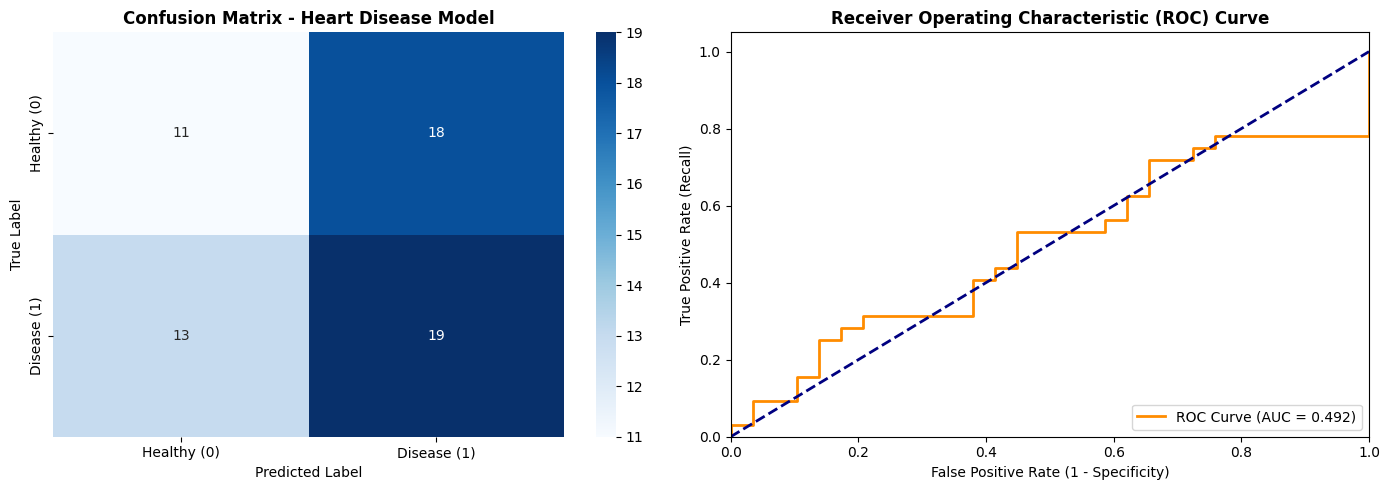

In [5]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)

print("==================================================")
print("       QUESTION 5: MODEL EVALUATION               ")
print("==================================================")

# Generate Predictions on Hold-Out Test Set
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

# Calculate Quantitative Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Hold-Out Test Evaluation Results:")
print(f" - Accuracy:  {acc:.4f} ({acc*100:.2f}%)")
print(f" - Precision: {prec:.4f}")
print(f" - Recall:    {rec:.4f}")
print(f" - F1-Score:  {f1:.4f}")

# Classification Report
print("\n--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Healthy (0)', 'Heart Disease (1)']))

# --- Confusion Matrix & ROC Visualizations ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Healthy (0)', 'Disease (1)'],
            yticklabels=['Healthy (0)', 'Disease (1)'])
axes[0].set_title('Confusion Matrix - Heart Disease Model', fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# Plot 2: ROC Curve & AUC Score
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate (1 - Specificity)')
axes[1].set_ylabel('True Positive Rate (Recall)')
axes[1].set_title('Receiver Operating Characteristic (ROC) Curve', fontweight='bold')
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()